In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
# first get into each trial folder
trial_number = 8
print(os.listdir("."))   
# format for trial folder is two digit number with leading zero if necessary
trial_folder = os.path.join("Baseline(recorded in silence)",f"trial_{trial_number:02d}")

['.venv', 'Baseline(recorded in silence)', 'plot_eeg_channels.py', 'quick_plot.html', 'quick_plot.ipynb']


In [10]:


trial_data = pd.read_csv(os.path.join(trial_folder, "eeg_data.csv"))

In [11]:
trial_data.head()

,timestamp,eeg1,eeg2,eeg3,eeg4,eeg5,eeg6,eeg7,eeg8,eeg9,...,eeg11,eeg12,eeg13,eeg14,eeg15,eeg16,eeg17,eeg18,eeg19,eeg20
0,05:04:52.739903,-53.407707,-46.890640,-57.379810,-63.938557,-69.650551,-51.372261,-53.304611,-62.165531,-52.907440,...,-56.687847,-62.737225,-78.557808,-66.554405,-66.728432,-66.886215,-56.594345,-70.654236,-51.390575,0.0
1,05:04:52.749918,-54.916706,-49.273598,-60.027534,-65.568199,-72.989586,-53.851131,-56.324455,-64.905144,-56.883232,...,-59.639637,-67.258141,-79.621475,-68.692680,-68.278473,-69.322777,-62.698261,-74.290428,-56.368187,0.0
2,05:04:52.760918,-52.218781,-46.665863,-58.263123,-63.443317,-70.704422,-50.554199,-56.106880,-59.607109,-54.923725,...,-55.509430,-64.858673,-72.793846,-64.617302,-63.479053,-66.015137,-62.536041,-70.715279,-54.512501,0.0
3,05:04:52.771899,-51.050510,-44.744545,-56.359081,-62.114880,-68.224434,-48.503822,-56.256943,-54.216202,-52.986263,...,-51.825798,-61.804127,-66.444603,-60.894638,-59.402817,-63.604961,-61.545559,-67.412498,-51.299950,0.0
4,05:04:52.781927,-43.945156,-37.571301,-47.285965,-54.440151,-59.902321,-42.010349,-48.326015,-43.665844,-44.609688,...,-42.653572,-52.763729,-56.004063,-51.753746,-50.254498,-54.738632,-52.496944,-58.588917,-42.045433,0.0


In [12]:
trial_data.describe()

,eeg1,eeg2,eeg3,eeg4,eeg5,eeg6,eeg7,eeg8,eeg9,eeg10,eeg11,eeg12,eeg13,eeg14,eeg15,eeg16,eeg17,eeg18,eeg19,eeg20
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0
mean,-19.372315,-19.071053,-19.315121,-14.946259,-20.183972,-12.951290,-20.099290,-22.622405,-4.233665,-11.848516,-31.411269,-22.924079,-17.746740,-15.575588,-17.485046,-16.926984,-21.753263,-24.750807,-20.049049,0.0
std,62.527446,64.502067,61.236613,61.022998,65.217962,65.002294,66.803352,77.025816,61.636897,63.789810,61.971644,64.591547,72.044532,63.508852,62.687552,63.992496,64.171877,64.219903,64.980604,0.0
min,-160.387405,-158.490891,-157.251205,-150.676422,-182.197754,-154.128372,-170.537506,-207.135910,-138.264984,-153.964233,-188.359863,-167.276093,-184.061386,-158.186920,-156.335724,-167.470856,-182.927277,-165.622803,-163.349396,0.0
25%,-75.521725,-75.431604,-74.130062,-69.363605,-71.214386,-67.669886,-76.719904,-77.111410,-57.023742,-68.398005,-78.469612,-78.336468,-72.240797,-68.906433,-71.723951,-71.145226,-75.978428,-78.370392,-72.765194,0.0
50%,-23.002222,-23.241435,-23.448844,-17.346698,-23.484466,-15.131839,-23.032356,-19.813527,-6.769607,-12.361965,-33.653576,-26.810601,-19.616562,-17.805869,-19.034067,-19.762308,-23.881672,-28.370005,-23.369976,0.0
75%,32.593170,35.300020,32.177257,38.881172,33.551991,43.027844,38.338275,40.104478,47.022292,42.354824,25.035832,31.949006,40.542143,39.113435,36.614098,37.266233,31.389233,28.686759,32.980314,0.0
max,122.148216,119.834068,118.740410,112.777771,125.191315,125.995506,123.317184,149.842972,138.708008,127.990669,107.872185,113.812263,154.692703,133.521408,123.253967,136.892380,120.098312,130.206085,138.745270,0.0


In [13]:
#05:01:13.064946 -> time format
#find statistics of how the timestep varies from index to index
trial_data['timestamp'] = pd.to_datetime(trial_data['timestamp'], format='%H:%M:%S.%f')
time_diffs = pd.to_datetime(trial_data['timestamp']).diff().dt.total_seconds().dropna()
print("Min:", time_diffs.min(), "seconds")
print("Max:", time_diffs.max(), "seconds")
print("Std:", time_diffs.std(), "seconds")
print("Mean:", time_diffs.mean(), "seconds")

#number of samples totally
print("Total samples:", len(trial_data))

#estimated time
estimated_time = time_diffs.sum()
print("Estimated time duration of trial:", estimated_time, "seconds")

# estimated sampling rate for fourier analysis
sampling_rate = 1 / time_diffs.mean()
print("Estimated sampling rate:", sampling_rate, "Hz")
estimated_sampling_rate_time = time_diffs.mean()*3000

# error check between assumed sampling rate and actual time duration
actual_duration = (trial_data['timestamp'].iloc[-1] - trial_data['timestamp'].iloc[0]).total_seconds()
print("Actual time duration of trial:", actual_duration, "seconds")
time_error = abs(actual_duration - estimated_sampling_rate_time)
print("Time duration error:", time_error, "seconds")

Min: 0.01 seconds
Max: 0.011671 seconds
Std: 0.0004567517276727414 seconds
Mean: 0.010459005335111703 seconds
Total samples: 3000
Estimated time duration of trial: 31.366556999999997 seconds
Estimated sampling rate: 95.6113863564943 Hz
Actual time duration of trial: 31.366557 seconds
Time duration error: 0.010459005335107463 seconds


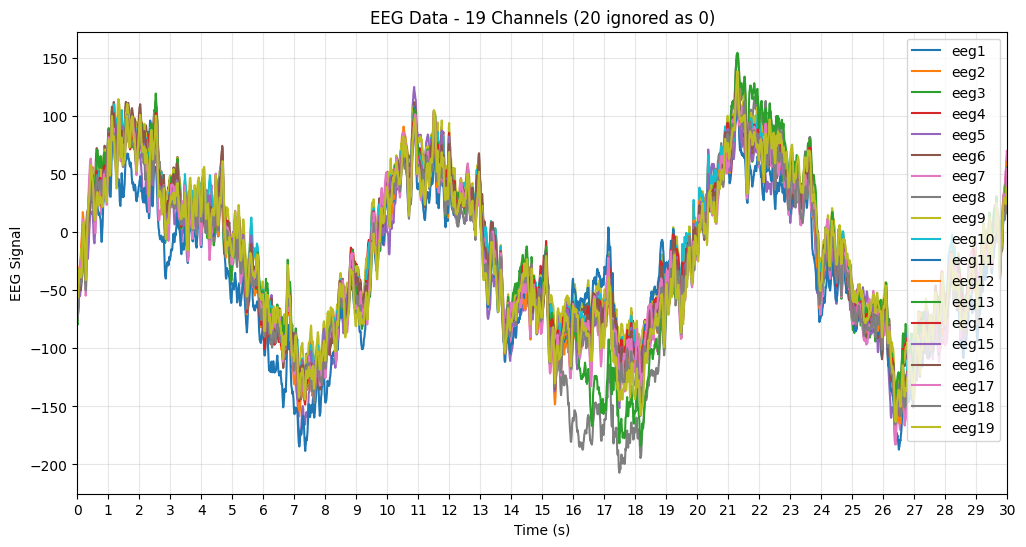

In [14]:
# using the sampling rate, plot the eeg data of one channel against time
time_axis = np.arange(len(trial_data)) / sampling_rate

plt.figure(figsize=(12, 6))
# plt.plot(time_axis, trial_data['eeg2'], label="eeg")
for i in range(len(trial_data.columns)-2):
    plt.plot(time_axis, trial_data.iloc[:, i+1], label=trial_data.columns[i+1])

plt.xlabel("Time (s)")
plt.ylabel("EEG Signal")
plt.title("EEG Data - 19 Channels (20 ignored as 0)")
plt.legend()

# ticks every 1 second till 30
plt.xticks(np.arange(0, 31, 1))
plt.xlim(0, 30)

plt.grid(True, alpha=0.3)
plt.show()

# Linear Regression Test (Time Series)

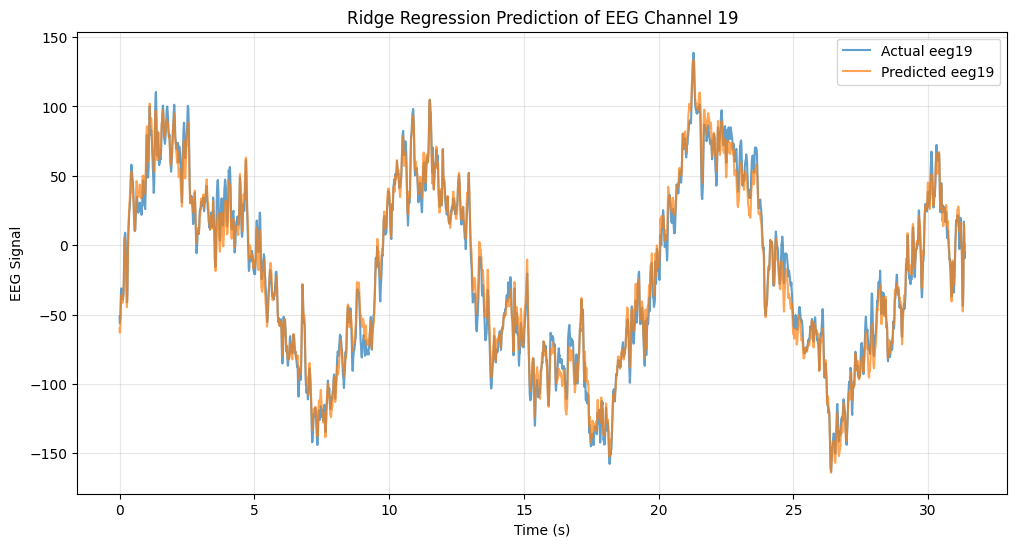

In [15]:
# do a simple difference test showing that we can reconstruct one channel
# from other channels by linear regression L2
# this would be simple ridge regression

from sklearn.linear_model import Ridge
#pick channels 1 through 18 and predict 19
X = trial_data.iloc[:, 1:19].values
y = trial_data['eeg19'].values
model = Ridge(alpha=1.0)
model.fit(X, y)
y_pred = model.predict(X)
plt.figure(figsize=(12, 6))
plt.plot(time_axis, y, label="Actual eeg19", alpha=0.7)
plt.plot(time_axis, y_pred, label="Predicted eeg19", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("EEG Signal")
plt.title("Ridge Regression Prediction of EEG Channel 19")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
#print error metrics like mean squared error and r2 score
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 57.14937302350047
R2 Score: 0.9864609318529357


### TimeSeries Conclusion: Baseline EEG data is almost indistinguishable from each channel.
### Inputs: Data could be biased or ground electrode may not be connected. This could just be static noise
### Action: Check the software if reference electrode and montage is properly configured.

# Fourier Analysis (Welch Power Spectral Distribution)

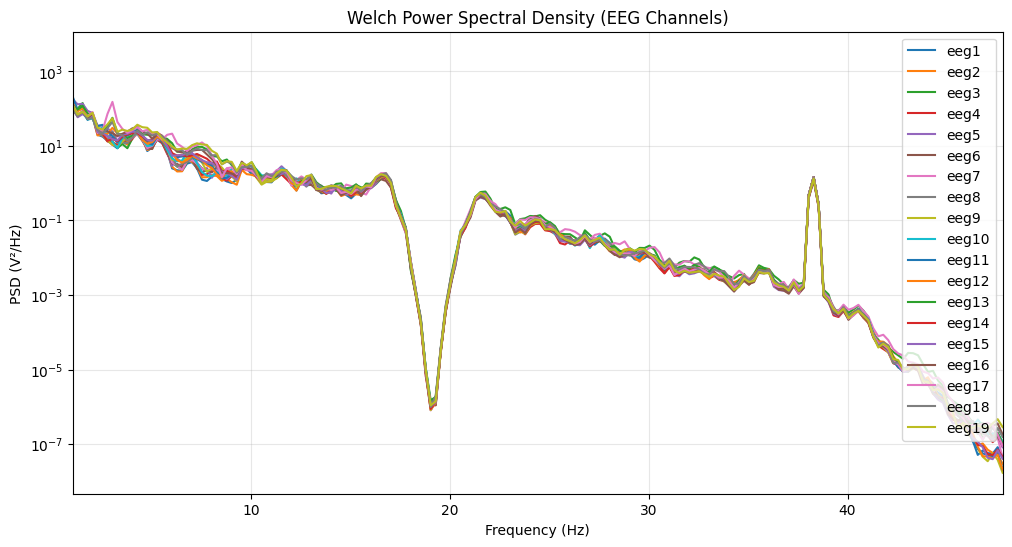

In [21]:
from scipy.signal import welch

plt.figure(figsize=(12, 6))

# assuming eeg channels start from column index 1 and end before last 1-2 cols
for i in range(len(trial_data.columns) - 2):
    ch_name = trial_data.columns[i+1]
    signal = trial_data.iloc[:, i+1].values

    # remove DC
    signal = signal - np.mean(signal)

    # Welch PSD
    freqs, psd = welch(
        signal,
        fs=sampling_rate,
        nperseg=4 * sampling_rate,   # 4-second window
        noverlap=2 * sampling_rate   # 50% overlap
    )

    plt.semilogy(freqs, psd, label=ch_name)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Welch Power Spectral Density (EEG Channels)")
plt.xlim(1, sampling_rate/2)   # EEG usually meaningful up to 50 Hz
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Fourier Series also looks similar for all channels. Check if reference electrode and montage is properly configured.